Quarters with negative real GDP growth: ['2009Q1', '2011Q3', '2020Q2', '2021Q2']
Macro: 264 months, 2004-07 to 2026-06
Market (fred): 835 monthly returns, 1957-02 to 2026-08
Sample: 2004-12 to 2026-03, 256 months
Stress months: 12 across 4 separate episode(s)
With this few episodes, treat any metric as suggestive, not proof.

--- Logistic regression ---
Out-of-sample months: 96  (stress months: 6)
AUC:       0.244
Recall:    0.167
Precision: 0.077
Confusion matrix [[TN FP] [FN TP]]:
[[78 12]
 [ 5  1]] 

--- Random forest ---
Out-of-sample months: 96  (stress months: 6)
AUC:       0.499
Recall:    0.000
Precision: 0.000
Confusion matrix [[TN FP] [FN TP]]:
[[90  0]
 [ 6  0]] 



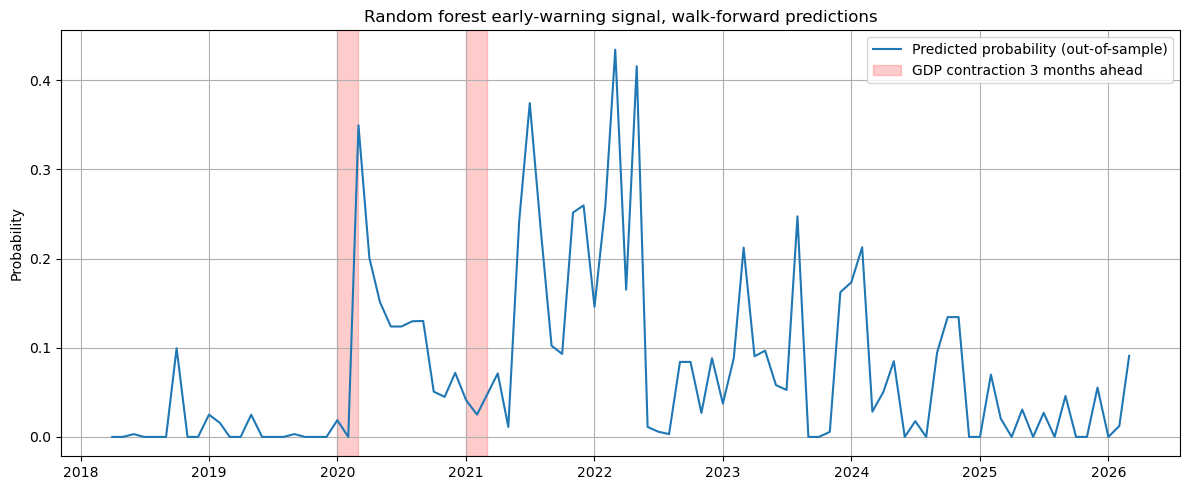

Feature importance (descriptive):
GDP_QoQ_%        0.373745
IIP_YoY_%        0.324684
Market_Return    0.301571
dtype: float64


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import roc_auc_score, recall_score, precision_score, confusion_matrix

FRED_URL = "https://fred.stlouisfed.org/graph/fredgraph.csv?id={}"
GDP_SERIES = "NAEXKP01INQ657S"
IIP_SERIES = "INDPRINTO01GYSAM"
GDP_FILE = None         
IIP_FILE = None        
MARKET_SOURCE = "fred"   
SHARE_SERIES = "SPASTT01INM661N"
NIFTY_CSV = None       
HORIZON = 3             
RELEASE_LAG = 5        
TEST_SIZE = 12         
N_SPLITS = 8

MACRO_COLS = ["GDP_QoQ_%", "IIP_YoY_%"]
LABEL_COL = "Contraction"      
def pull(series_id, local_file=None):
    try:
        df = pd.read_csv(local_file or FRED_URL.format(series_id))
    except Exception as err:
        raise RuntimeError(f"Could not load {series_id} ({err}). Download it from "
                           f"https://fred.stlouisfed.org/series/{series_id} and set the "
                           f"GDP_FILE / IIP_FILE setting to the saved csv.")
    df = df.iloc[:, :2]
    df.columns = ["date", "value"]                       
    df["date"] = pd.to_datetime(df["date"])
    df["value"] = pd.to_numeric(df["value"], errors="coerce")   
    return df.set_index("date")["value"].dropna()


def get_macro():
    gdp = pull(GDP_SERIES, GDP_FILE)
    gdp.index = gdp.index.to_period("Q")                 # dates are the first day of each quarter

    iip = pull(IIP_SERIES, IIP_FILE)
    q = iip.index.to_period("Q")
    iip_q = iip.groupby(q).mean()
    iip_q = iip_q[iip.groupby(q).count() == 3]           # keep only quarters with all 3 months

    macro = pd.DataFrame({"GDP_QoQ_%": gdp, "IIP_YoY_%": iip_q}).dropna()
    macro[LABEL_COL] = (macro["GDP_QoQ_%"] < 0).astype(int)
    print("Quarters with negative real GDP growth:", [str(p) for p in macro.index[macro[LABEL_COL] == 1]])

    # each quarter's value applies to all three of its months
    first_month = macro.index.asfreq("M", how="start")
    last_month = macro.index.max().asfreq("M", how="end")
    monthly = macro.copy()
    monthly.index = first_month
    monthly = monthly.reindex(pd.period_range(first_month.min(), last_month, freq="M")).ffill()
    print(f"Macro: {len(monthly)} months, {monthly.index[0]} to {monthly.index[-1]}")
    return monthly


def get_market_returns():
    if MARKET_SOURCE == "fred":
        close = pull(SHARE_SERIES)
    elif NIFTY_CSV:
        close = pd.read_csv(NIFTY_CSV, parse_dates=["Date"], index_col="Date")["Close"]
    else:
        import yfinance as yf
        raw = yf.download("^NSEI", start="2007-12-01", end=None,
                          auto_adjust=True, progress=False)
        if raw is None or raw.empty:
            raise RuntimeError("Nifty download came back empty. Set MARKET_SOURCE = 'fred', "
                               "or run %pip install -U yfinance and restart the kernel.")
        close = raw["Close"]
        if isinstance(close, pd.DataFrame):
            close = close.iloc[:, 0]

    close = pd.to_numeric(close, errors="coerce").dropna().sort_index()
    close.index = pd.to_datetime(close.index)
    if len(close) == 0:
        raise RuntimeError("Market prices are all missing after cleaning - check the source.")

    # last value of each month, indexed by calendar month
    monthly = close.groupby(close.index.to_period("M")).last()
    returns = monthly.pct_change().dropna()
    print(f"Market ({MARKET_SOURCE}): {len(returns)} monthly returns, {returns.index[0]} to {returns.index[-1]}")
    return returns.rename("Market_Return")


def build_dataset():
    macro = get_macro()
    market = get_market_returns()

    data = macro.join(market, how="inner")
    if data.empty:
        raise RuntimeError(f"Macro and market series share no months. Macro: {macro.index[0]} to "
                           f"{macro.index[-1]}, Market: {market.index[0]} to {market.index[-1]}")

    # quarterly numbers aren't known during the quarter, so push them back by the release lag
    data[MACRO_COLS] = data[MACRO_COLS].shift(RELEASE_LAG)

    # what we're predicting: a contraction HORIZON months from now
    data["Target"] = data[LABEL_COL].shift(-HORIZON)

    needed = MACRO_COLS + ["Market_Return", "Target"]
    clean = data.dropna(subset=needed)
    if clean.empty:
        print("Missing values per column:\n", data[needed].isna().sum())
        raise RuntimeError("Nothing left after dropping missing values - see counts above.")
    if clean["Target"].nunique() < 2:
        raise RuntimeError("The label column has only one value in this sample.")
    return clean


# ---------------- validation ----------------
def walk_forward(model, X, y):
    # train on the past, test on the next block; the gap stops overlapping
    # forward-looking labels from leaking across the train/test boundary
    splitter = TimeSeriesSplit(n_splits=N_SPLITS, test_size=TEST_SIZE, gap=HORIZON)
    probs = pd.Series(np.nan, index=X.index)
    for train_idx, test_idx in splitter.split(X):
        if y.iloc[train_idx].nunique() < 2:
            continue                      # nothing to learn from yet
        model.fit(X.iloc[train_idx], y.iloc[train_idx])
        probs.iloc[test_idx] = model.predict_proba(X.iloc[test_idx])[:, 1]
    return probs.dropna()


def report(name, probs, y):
    print(f"--- {name} ---")
    if len(probs) == 0:
        print("No usable test blocks (training data never had both classes).\n")
        return
    actual = y.loc[probs.index]
    if actual.nunique() < 2:
        print("Out-of-sample period has only one class, so AUC is undefined.\n")
        return
    pred = (probs >= 0.5).astype(int)
    print(f"Out-of-sample months: {len(actual)}  (stress months: {int(actual.sum())})")
    print(f"AUC:       {roc_auc_score(actual, probs):.3f}")
    print(f"Recall:    {recall_score(actual, pred):.3f}")
    print(f"Precision: {precision_score(actual, pred, zero_division=0):.3f}")
    print("Confusion matrix [[TN FP] [FN TP]]:")
    print(confusion_matrix(actual, pred), "\n")


# ---------------- run ----------------
if __name__ == "__main__":
    data = build_dataset()
    y = data["Target"].astype(int)

    episodes = int(((y == 1) & (y.shift(1, fill_value=0) == 0)).sum())
    print(f"Sample: {data.index[0].strftime('%Y-%m')} to {data.index[-1].strftime('%Y-%m')}, "
          f"{len(data)} months")
    print(f"Stress months: {int(y.sum())} across {episodes} separate episode(s)")
    print("With this few episodes, treat any metric as suggestive, not proof.\n")

    models = {
        "Logistic regression": make_pipeline(
            StandardScaler(), LogisticRegression(class_weight="balanced", max_iter=1000)),
        "Random forest": RandomForestClassifier(
            n_estimators=300, min_samples_leaf=3, class_weight="balanced", random_state=42),
    }

    features = MACRO_COLS + ["Market_Return"]
    results = {}
    for name, model in models.items():
        results[name] = walk_forward(model, data[features], y)
        report(name, results[name], y)

    # chart of out-of-sample probabilities only
    p = results["Random forest"]
    if len(p) > 0:
        dates = p.index.to_timestamp()
        stress = (y.loc[p.index].values == 1)
        fig, ax = plt.subplots(figsize=(12, 5))
        ax.plot(dates, p.values, label="Predicted probability (out-of-sample)")
        ax.fill_between(dates, 0, 1, where=stress, alpha=0.2, color="red",
                        transform=ax.get_xaxis_transform(),
                        label=f"GDP contraction {HORIZON} months ahead")
        ax.set_title("Random forest early-warning signal, walk-forward predictions")
        ax.set_ylabel("Probability")
        ax.legend()
        ax.grid(True)
        fig.tight_layout()
        fig.savefig("oos_stress_probability.png", dpi=200)
        plt.show()

    # importances from a fit on all data: descriptive only, not evidence of causes
    rf = models["Random forest"].fit(data[features], y)
    print("Feature importance (descriptive):")
    print(pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False))